# Notebook 02: Data Cleaning
## Netflix Content Strategy Analysis

**Business Context**: Before any analysis can begin, data quality must be established. This notebook applies a systematic 9-step cleaning pipeline to the raw Netflix dataset. Every decision is documented with rationale so the process is fully reproducible.

**Input**: `data/raw/netflix_titles.csv`  
**Output**: `data/processed/netflix_cleaned.csv` + `netflix_cleaned.parquet`

**Cleaning Steps**:
1. Drop duplicates
2. Fix data types
3. Parse `date_added` → datetime
4. Parse `duration` → numeric columns
5. Normalize country names
6. Standardize ratings
7. Handle missing values (with flags)
8. Standardize text fields
9. Split genres into list

## 0. Setup & Imports

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from src.config import RAW_CSV, CLEANED_CSV, CLEANED_PARQUET, ensure_dirs
from src.utils import load_csv, missing_summary, quick_profile, save_csv, save_parquet
from src.cleaning import (
    run_cleaning_pipeline,
    drop_duplicates,
    fix_dtypes,
    parse_date_added,
    parse_duration,
    normalize_countries,
    standardize_ratings,
    handle_missing_values,
    standardize_text,
    split_genres,
)

ensure_dirs()
print('Setup complete.')

Setup complete.


## 1. Load Raw Dataset

In [2]:
df_raw = load_csv(RAW_CSV)
print(f'Raw dataset shape: {df_raw.shape}')
display(df_raw.head(3))

13:01:07 | INFO | Loaded netflix_titles.csv: 8,807 rows × 12 cols


Raw dataset shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


## 2. Step-by-Step Cleaning

We apply each cleaning step individually so we can verify the result before moving on.
The full pipeline can be run via `run_cleaning_pipeline(df)` for production use.

### Step 1: Drop Duplicates

**Rationale**: Duplicate rows would inflate counts in all analyses. We remove fully duplicate rows and rows with duplicate `show_id`.

In [3]:
df = df_raw.copy()
before = len(df)
df = drop_duplicates(df)
print(f'Rows before: {before:,}  |  After: {len(df):,}  |  Removed: {before - len(df)}')

13:01:07 | INFO | Dropped 0 duplicate rows.


Rows before: 8,807  |  After: 8,807  |  Removed: 0


### Step 2: Fix Data Types

**Rationale**: `release_year` should be an integer. All text fields should be string dtype for consistent operations.

In [4]:
df = fix_dtypes(df)
display(df.dtypes.to_frame('dtype'))

13:01:07 | INFO | Fixed column dtypes.


,dtype
show_id,string[python]
type,string[python]
title,string[python]
director,string[python]
cast,string[python]
country,string[python]
date_added,object
release_year,Int64
rating,string[python]
duration,string[python]


### Step 3: Parse `date_added`

**Rationale**: `date_added` is stored as a string ('January 1, 2020'). We parse it to `datetime64` so we can extract year, month, and weekday features.

In [5]:
df = parse_date_added(df)
print(f'dtype after parsing: {df["date_added"].dtype}')
print(f'NaT count: {df["date_added"].isna().sum()}')
display(df['date_added'].dropna().head(5))

13:01:07 | INFO | Parsed date_added. 10 rows have NaT (could not be parsed).


dtype after parsing: datetime64[ns]
NaT count: 10


0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]

### Step 4: Parse `duration`

**Rationale**: The `duration` column is mixed — '90 min' for movies and '3 Seasons' for TV shows. We split it into two numeric columns: `duration_minutes` and `duration_seasons`.

In [6]:
df = parse_duration(df)
print('Movie durations (minutes) — sample:')
print(df[df['type'] == 'Movie']['duration_minutes'].describe())
print('\nTV Show seasons — sample:')
print(df[df['type'] == 'TV Show']['duration_seasons'].describe())

13:01:07 | INFO | Parsed duration into duration_minutes and duration_seasons.


Movie durations (minutes) — sample:


count       6128.0
mean     99.577187
std      28.290593
min            3.0
25%           87.0
50%           98.0
75%          114.0
max          312.0
Name: duration_minutes, dtype: Float64

TV Show seasons — sample:
count      2676.0
mean     1.764948
std      1.582752
min           1.0
25%           1.0
50%           1.0
75%           2.0
max          17.0
Name: duration_seasons, dtype: Float64


### Step 5: Normalize Country Names

**Rationale**: Country names contain abbreviations ('US', 'UK') and historical names ('West Germany'). We standardize these for consistent grouping in country analysis.

In [7]:
df = normalize_countries(df)
print('Top 10 countries after normalization:')
print(
    df['country'].dropna()
    .str.split(',').explode().str.strip()
    .value_counts().head(10)
)

13:01:07 | INFO | Normalized country names.


Top 10 countries after normalization:
country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            231
Mexico             169
Name: count, dtype: int64


### Step 6: Standardize Ratings

**Rationale**: Some rows have duration strings ('74 min') mistakenly placed in the `rating` column. These are removed. 'UR' is unified with 'NR' (Not Rated).

In [8]:
df = standardize_ratings(df)
print('Unique ratings after standardization:')
print(sorted(df['rating'].dropna().unique()))

13:01:07 | INFO | Standardized ratings.


Unique ratings after standardization:
['G', 'NC-17', 'NR', 'PG', 'PG-13', 'R', 'TV-14', 'TV-G', 'TV-MA', 'TV-PG', 'TV-Y', 'TV-Y7', 'TV-Y7-FV']


### Step 7: Handle Missing Values

**Strategy**:
| Column | Strategy | Reasoning |
|--------|----------|----------|
| `director` | Fill with 'Unknown Director' | Cannot impute; marking preserves rows |
| `cast` | Fill with 'Unknown Cast' | Same as above |
| `country` | Fill with 'Unknown' | Same as above |
| `rating` | Fill with 'Not Rated' | Standard label for unrated content |
| `date_added` | Leave as NaT | Imputing dates would fabricate trends |

Boolean flags are added for originally-missing columns for use in missing value analysis.

In [9]:
df = handle_missing_values(df)
print('Missing values after handling:')
remaining = df.isnull().sum()
print(remaining[remaining > 0])
print(f'\nRows flagged as director_missing: {df["director_missing"].sum()}')
print(f'Rows flagged as cast_missing: {df["cast_missing"].sum()}')

13:01:07 | INFO | Handled missing values.


Missing values after handling:
date_added            10
duration_minutes    2679
duration_seasons    6131
dtype: int64

Rows flagged as director_missing: 2634
Rows flagged as cast_missing: 825


### Step 8: Standardize Text

**Rationale**: Strip extra whitespace from all text columns to prevent grouping errors (e.g., ' United States' vs 'United States').

In [10]:
df = standardize_text(df)
print('Text standardization complete.')
display(df[['title', 'type', 'listed_in']].head(5))

13:01:07 | INFO | Standardized text fields.


Text standardization complete.


,title,type,listed_in
0,Dick Johnson Is Dead,Movie,Documentaries
1,Blood & Water,Tv Show,"International TV Shows, TV Dramas, TV Mysteries"
2,Ganglands,Tv Show,"Crime TV Shows, International TV Shows, TV Act..."
3,Jailbirds New Orleans,Tv Show,"Docuseries, Reality TV"
4,Kota Factory,Tv Show,"International TV Shows, Romantic TV Shows, TV ..."


### Step 9: Split Genres

**Rationale**: The `listed_in` column stores comma-separated genres as a single string. We split this into a Python list stored in the `genres` column for easier genre-level analysis.

In [11]:
df = split_genres(df)
print('Sample genres column:')
display(df[['title', 'listed_in', 'genres']].head(5))

13:01:07 | INFO | Split genres into list column 'genres'.


Sample genres column:


,title,listed_in,genres
0,Dick Johnson Is Dead,Documentaries,[Documentaries]
1,Blood & Water,"International TV Shows, TV Dramas, TV Mysteries","[International TV Shows, TV Dramas, TV Mysteries]"
2,Ganglands,"Crime TV Shows, International TV Shows, TV Act...","[Crime TV Shows, International TV Shows, TV Ac..."
3,Jailbirds New Orleans,"Docuseries, Reality TV","[Docuseries, Reality TV]"
4,Kota Factory,"International TV Shows, Romantic TV Shows, TV ...","[International TV Shows, Romantic TV Shows, TV..."


## 3. Final Dataset Verification

In [12]:
print('=== CLEANED DATASET SUMMARY ===')
quick_profile(df)
print(f'\nNew columns added: {[c for c in df.columns if c not in df_raw.columns]}')
display(df.head(3))

=== CLEANED DATASET SUMMARY ===
──────────────────────────────────────────────────
Shape          : 8,807 rows × 19 columns
Memory usage   : 9.33 MB


Missing cells  : 8,820


Duplicate rows : 0
──────────────────────────────────────────────────
show_id             string[python]
type                string[python]
title               string[python]
director            string[python]
cast                string[python]
country                     object
date_added          datetime64[ns]
release_year                 Int64
rating                      object
duration                    object
listed_in           string[python]
description         string[python]
duration_minutes             Int64
duration_seasons             Int64
director_missing              bool
cast_missing                  bool
country_missing               bool
rating_missing                bool
genres                      object
──────────────────────────────────────────────────

New columns added: ['duration_minutes', 'duration_seasons', 'director_missing', 'cast_missing', 'country_missing', 'rating_missing', 'genres']


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_minutes,duration_seasons,director_missing,cast_missing,country_missing,rating_missing,genres
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown Cast,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,<NA>,False,True,False,False,[Documentaries]
1,s2,Tv Show,Blood & Water,Unknown Director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",<NA>,2,True,False,False,False,"[International TV Shows, TV Dramas, TV Mysteries]"
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,<NA>,1,False,False,True,False,"[Crime TV Shows, International TV Shows, TV Ac..."


## 4. Before vs After Comparison

Visual comparison of missing value improvement after cleaning.

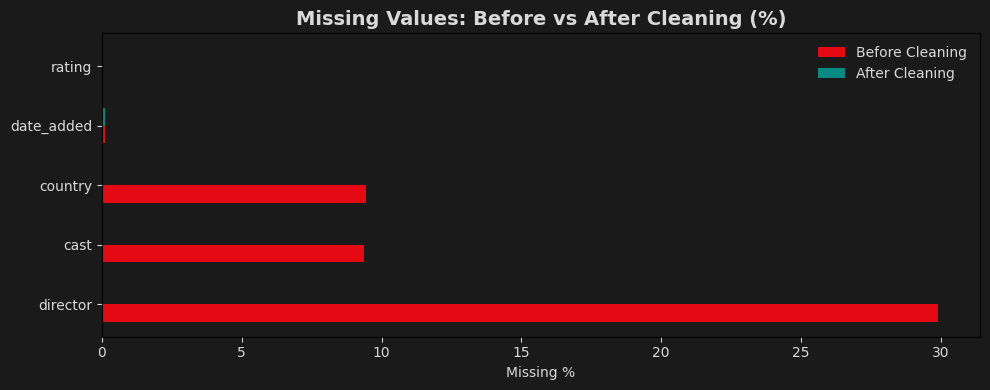

In [13]:
cols_of_interest = ['director', 'cast', 'country', 'date_added', 'rating']
before_pct = (df_raw[cols_of_interest].isnull().sum() / len(df_raw) * 100).rename('Before Cleaning')
after_pct  = (df[cols_of_interest].isnull().sum() / len(df) * 100).rename('After Cleaning')

comparison = pd.concat([before_pct, after_pct], axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
comparison.plot.barh(ax=ax, color=['#E50914', '#048A81'], edgecolor='none', width=0.6)
ax.set_title('Missing Values: Before vs After Cleaning (%)',
             fontsize=14, fontweight='bold', color='#D9D9D9')
ax.set_xlabel('Missing %', color='#D9D9D9')
ax.set_facecolor('#1A1A1A')
fig.patch.set_facecolor('#1A1A1A')
ax.tick_params(colors='#D9D9D9')
ax.legend(frameon=False, labelcolor='#D9D9D9')
plt.tight_layout()
plt.show()

## 5. Export Cleaned Dataset

In [14]:
# Prepare for export — convert list column to string for CSV
df_export = df.copy()
df_export['genres'] = df_export['genres'].apply(
    lambda g: ', '.join(g) if isinstance(g, list) else ''
)

# CSV export
save_csv(df_export, CLEANED_CSV)

# Parquet export (retains original list column)
df_parquet = df.copy()
df_parquet['genres'] = df_parquet['genres'].apply(
    lambda g: str(g) if isinstance(g, list) else ''
)
save_parquet(df_parquet, CLEANED_PARQUET)

print('Export complete!')
print(f'CSV   → {CLEANED_CSV}')
print(f'Parquet → {CLEANED_PARQUET}')

13:01:08 | INFO | Saved CSV  → D:\DataAnalyst\Netflix-Content-Strategy-Analysis\data\processed\netflix_cleaned.csv  (8,807 rows)


13:01:08 | INFO | Saved Parquet → D:\DataAnalyst\Netflix-Content-Strategy-Analysis\data\processed\netflix_cleaned.parquet  (8,807 rows)


Export complete!
CSV   → D:\DataAnalyst\Netflix-Content-Strategy-Analysis\data\processed\netflix_cleaned.csv
Parquet → D:\DataAnalyst\Netflix-Content-Strategy-Analysis\data\processed\netflix_cleaned.parquet


## 6. Cleaning Summary

| Step | Action | Business Impact |
|------|--------|-----------------|
| Duplicates | Removed duplicate rows | Prevents inflated counts |
| Dtypes | Fixed release_year, text columns | Enables numeric operations |
| date_added | Parsed to datetime | Enables time-series analysis |
| duration | Split into minutes/seasons | Enables duration analysis |
| country | Normalized names | Enables accurate country grouping |
| rating | Removed anomalies, unified NR/UR | Ensures clean rating distribution |
| missing | Filled with domain-appropriate values | Retains all rows for analysis |
| text | Stripped whitespace | Prevents false grouping |
| genres | Split into list | Enables genre-level analysis |

**Next Step**: Proceed to `03_feature_engineering.ipynb`